<a href="https://colab.research.google.com/github/Ayomide-baga/CMP7005-PRAC1/blob/main/CMP7005_PRAC1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMP7005 Programming for Data Analysis — PRAC1
## From Data to Application Development
### Beijing Air Quality Analysis

**Student ID:** ST20349610  
**Module Leader:** aprasad@cardiffmet.ac.uk

## Research Context

Air pollution is one of the most pressing global public health challenges
of the 21st century. The World Health Organization estimates that ambient
air pollution contributes to millions of premature deaths annually, with
the greatest burden falling on rapidly developing urban centres (WHO, 2021).
Among the various pollutants monitored, PM2.5 — fine particulate matter
with a diameter of 2.5 micrometres or less — poses the most significant
health risk, as these particles are small enough to penetrate deep into
the lungs and enter the bloodstream, increasing the risk of cardiovascular
disease, respiratory illness, and lung cancer (Brauer et al., 2021).

Beijing, the capital of China, has experienced persistently poor air
quality over the past two decades, driven by rapid economic expansion,
heavy industrialisation, and growing vehicle emissions (Xu and Zhang, 2020).
In response, the Chinese government has implemented aggressive emission
control policies, including coal-to-gas conversion for residential heating,
stricter vehicle emission standards, and industrial relocation away from
the city centre (Li et al., 2024). Understanding whether these interventions
have had a measurable impact requires systematic, data-driven analysis of
long-term monitoring records.

Projects of this nature are critical for several reasons. First, they
transform raw monitoring data into actionable insights — identifying
which pollutants are most problematic, when and where pollution is worst,
and what factors drive it. Second, they enable evidence-based policy
evaluation — without rigorous analysis, it is impossible to determine
whether costly intervention measures are working. Third, predictive
modelling can support early warning systems, allowing authorities to
issue health advisories before pollution reaches dangerous levels.
Finally, interactive applications make these insights accessible to
non-technical stakeholders — policymakers, public health officials, and
citizens — who need clear, navigable information to make informed decisions.

This analysis uses hourly air quality data from four monitoring stations
across Beijing's urban-suburban gradient (March 2013 - February 2017) to
address the following research questions:

1. How do pollutant concentrations and AQI health categories differ
   between urban (Dongsi, Tiantan) and suburban (Dingling, Huairou)
   stations, and is this gradient consistent across seasons and times
   of day?

2. What meteorological and temporal factors - including wind speed,
   temperature, season, and hour of day - most strongly influence
   PM2.5 variability, and do these drivers differ between urban and
   suburban environments?

3. Has Beijing's air quality measurably improved over the 2013–2017
   period in response to emission control policies, and which
   pollutants show the greatest change?

4. Can PM2.5 concentrations be reliably predicted from co-pollutant
   and meteorological measurements using machine learning, and which
   features are most important for prediction accuracy?

These questions inform every stage of the analysis — from station
selection (Task 1), through exploratory analysis (Task 2), to
predictive modelling (Task 3) and the interactive application (Task 4).

### Dataset Overview

This analysis uses hourly air quality data from the Beijing Multi-Site
Air Quality dataset, collected from nationally controlled monitoring
stations between 1 March 2013 and 28 February 2017. Each record contains
six pollutant measurements (PM2.5, PM10, SO2, NO2, CO, O3) and five
meteorological variables (temperature, pressure, dew point, rainfall,
wind speed), along with wind direction and station identifier. Four
stations were selected - two urban (Dongsi, Tiantan) and two suburban
(Dingling, Huairou) - to enable spatial comparison across Beijing's
urban-suburban gradient.

## Task 1: Data Selection & Handling

### 1.1 Station Selection

For this analysis, **two urban (inner)** and **two suburban (outer)** monitoring stations were selected from Beijing's 12 nationally controlled air quality monitoring sites.

**Urban stations selected: Dongsi and Tiantan**  
**Suburban stations selected: Dingling and Huairou**

Xu and Zhang (2020) classify eight of the twelve Beijing monitoring stations as urban (Aotizhongxin, Dongsi, Guanyuan, Nongzhanguan, Tiantan, Wanshouxigong, Gucheng, and Haidian) and four as suburban (Changping, Dingling, Huairou, and Shunyi).

**Dongsi** is located in Beijing's Dongcheng District within the capital core zone (Z4), surrounded by dense residential neighbourhoods and heavy traffic, making it highly representative of inner-city pollution (Batterman et al., 2016).

**Tiantan** (Temple of Heaven) sits in the southern urban area, capturing pollution from local traffic and regional transport from the industrialised south (Guo et al., 2019).

**Dingling** is classified as a background/contrast station in a mountainous, forested area far from urban emissions (Batterman et al., 2016).

**Huairou** lies within the ecological conservation zone, representing the cleanest conditions among the 12 stations (Batterman et al., 2016).

This selection enables comparison across the urban–suburban gradient.

### 1.2 Setting Up the Environment

In [2]:
# Importing the necessary libraries for data analysis
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

In [3]:
! git config --global user.name "Ayomide-baga"
! git config --global user.email "bamigbopaayomide@gmail.com"

In [4]:
username = "Ayomide-baga"
repo = "CMP7005-PRAC1"

In [5]:
! git clone https://@github.com/{username}/{repo}

Cloning into 'CMP7005-PRAC1'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 27 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 3.00 MiB | 3.79 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [6]:
%cd {repo}

/content/CMP7005-PRAC1


In [7]:
%ls

CMP7005_PRAC1.ipynb
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_Tiantan_20130301-20170228.csv
README.md


### 1.3 Loading and Merging the Datasets

In [8]:
# Loading all station CSV files from the repository
city_files = glob.glob("*.csv")

dataframes = []
for file_name in city_files:
    city_df = pd.read_csv(file_name)
    dataframes.append(city_df)
    print(f"Loaded: {file_name}")

# Merging into a single unified dataset
df = pd.concat(dataframes, ignore_index=True)

# Confirmation
print(f"\nSUCCESS: Combined {len(city_files)} city files into one file with {len(df)} total rows")
print(f"Columns: {df.shape[1]}")
print(f"Stations: {df['station'].unique()}")

Loaded: PRSA_Data_Dongsi_20130301-20170228.csv
Loaded: PRSA_Data_Tiantan_20130301-20170228.csv
Loaded: PRSA_Data_Dingling_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv

SUCCESS: Combined 4 city files into one file with 140256 total rows
Columns: 18
Stations: ['Dongsi' 'Tiantan' 'Dingling' 'Huairou']


In [9]:
# Create a proper datetime column from individual time components
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])

# Set as index for time-series analysis
df.set_index('datetime', inplace=True)

# Verify the date range and structure
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"\nRecords per station:")
print(df['station'].value_counts())
df.head()

Date range: 2013-03-01 00:00:00 to 2017-02-28 23:00:00

Records per station:
station
Dongsi      35064
Tiantan     35064
Dingling    35064
Huairou     35064
Name: count, dtype: int64


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
2013-03-01 01:00:00,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2013-03-01 02:00:00,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
2013-03-01 03:00:00,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
2013-03-01 04:00:00,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [10]:

df.to_csv('merged_air_quality.csv')
print("Merged dataset saved as 'merged_air_quality.csv'")

Merged dataset saved as 'merged_air_quality.csv'


### 1.4 Summary

Four station datasets (Dongsi, Tiantan, Dingling, and Huairou) were successfully loaded and merged into a single unified DataFrame containing 140,256 rows and 18 columns, covering the period from 1 March 2013 to 28 February 2017. Each station contributes 35,064 hourly records. A datetime index was created from the individual year, month, day, and hour columns to facilitate time-series analysis. Station identifiers are preserved in the 'station' column to enable inter-station comparisons throughout the analysis. Some missing values are visible in the initial inspection and will be addressed in Task 2.

## Task 2: Exploratory Data Analysis (EDA)
### 2.1 Data Understanding

In [11]:
# Number of rows and columns
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Column names and data types
print("Column descriptions and data types:")
print(df.dtypes)

Dataset shape: 140256 rows, 18 columns

Column descriptions and data types:
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object


In [12]:
# Detailed dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 140256 entries, 2013-03-01 00:00:00 to 2017-02-28 23:00:00
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       140256 non-null  int64  
 1   year     140256 non-null  int64  
 2   month    140256 non-null  int64  
 3   day      140256 non-null  int64  
 4   hour     140256 non-null  int64  
 5   PM2.5    137097 non-null  float64
 6   PM10     137673 non-null  float64
 7   SO2      136765 non-null  float64
 8   NO2      135038 non-null  float64
 9   CO       132499 non-null  float64
 10  O3       136384 non-null  float64
 11  TEMP     140112 non-null  float64
 12  PRES     140113 non-null  float64
 13  DEWP     140110 non-null  float64
 14  RAIN     140110 non-null  float64
 15  wd       139658 non-null  object 
 16  WSPM     140136 non-null  float64
 17  station  140256 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 20.3+ MB


In [13]:
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
2013-03-01 01:00:00,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2013-03-01 02:00:00,3,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
2013-03-01 03:00:00,4,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
2013-03-01 04:00:00,5,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi


In [14]:
df.tail()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,,
2017-02-28 19:00:00,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
2017-02-28 20:00:00,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
2017-02-28 21:00:00,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
2017-02-28 22:00:00,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou
2017-02-28 23:00:00,35064,2017,2,28,23,11.0,20.0,2.0,27.0,400.0,77.0,6.7,1009.3,-13.6,0.0,NE,1.9,Huairou


In [15]:
# Statistical summary of numerical columns
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,140256.000,140256.000000,140256.000000,140256.000000,140256.000000,137097.000000,137673.000000,136765.000000,135038.000000,132499.000000,136384.000000,140112.000000,140113.000000,140110.000000,140110.000000,140136.000000
mean,17532.500,2014.662560,6.522930,15.729637,11.500000,76.008598,97.999255,14.197895,41.772859,1137.793764,60.366923,13.368759,1010.114517,2.159931,0.064086,1.806885
std,10122.141,1.177201,3.448715,8.800123,6.922211,78.468402,88.648097,19.734570,32.142645,1064.570208,56.640642,11.521420,10.482069,13.879616,0.794380,1.271235
min,1.000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750,2014.000000,4.000000,8.000000,5.750000,18.000000,32.000000,2.000000,17.000000,400.000000,16.000000,3.000000,1001.700000,-9.400000,0.000000,1.000000
50%,17532.500,2015.000000,7.000000,16.000000,11.500000,51.000000,75.000000,6.000000,34.000000,800.000000,50.000000,14.400000,1009.800000,2.600000,0.000000,1.400000
75%,26298.250,2016.000000,10.000000,23.000000,17.250000,106.000000,136.000000,17.000000,60.000000,1400.000000,84.000000,23.100000,1018.300000,14.900000,0.000000,2.300000
max,35064.000,2017.000000,12.000000,31.000000,23.000000,881.000000,993.000000,315.000000,258.000000,10000.000000,1071.000000,41.400000,1042.000000,29.100000,52.100000,12.900000


#### Interpretation — Statistical Summary

**Count:** All 140,256 entries are present across time component columns
and station identifiers. Pollutant columns show slightly fewer non-null
values due to missing data (addressed in preprocessing).

**Date Range:** The dataset spans from 1 March 2013 to 28 February 2017,
covering exactly 4 years of hourly monitoring data across all four stations.

**Mean (Average Levels):**
- PM2.5 = 76.0 µg/m³ — exceeds the WHO annual guideline of 15 µg/m³ by
  a factor of five, indicating persistently poor air quality
- PM10 = 98.0 µg/m³ — well above the WHO guideline of 45 µg/m³, reflecting
  heavy particulate pollution from dust and combustion
- SO2 = 14.2 µg/m³ — relatively low, suggesting some effectiveness of
  sulphur emission controls
- NO2 = 41.8 µg/m³ — elevated levels consistent with heavy traffic emissions
- CO = 1137.8 µg/m³ — moderate average but with extreme spikes
- O3 = 60.4 µg/m³ — moderate, driven by photochemical formation in warmer months

**Min and Max:**
- PM2.5 ranges from 2 to 881 µg/m³ — the maximum represents extreme
  pollution episodes far exceeding hazardous thresholds
- CO ranges from 100 to 10,000 µg/m³ — the maximum is disproportionately
  large and may represent measurement anomalies or severe industrial events
- Temperature ranges from -19.9°C to 41.4°C — consistent with Beijing's
  continental climate with extreme seasonal variation
- Rainfall has a maximum of 52.1 mm/hour but a mean of only 0.064,
  confirming that precipitation events are rare but intense

**Spread (Standard Deviation):**
- PM2.5 std of 78.5 on a mean of 76.0 indicates extremely high variability —
  the standard deviation nearly equals the mean, characteristic of episodic
  pollution behaviour where conditions can shift dramatically within hours
- Temperature std of 11.5°C reflects the wide seasonal swing between
  Beijing's harsh winters and hot summers

#### Column Descriptions

| Column | Description | Unit | Type |
|--------|-------------|------|------|
| year, month, day, hour | Timestamp components | - | Temporal |
| PM2.5 | Fine particulate matter (≤2.5µm diameter) | µg/m³ | Pollutant |
| PM10 | Coarse particulate matter (≤10µm diameter) | µg/m³ | Pollutant |
| SO2 | Sulphur dioxide | µg/m³ | Pollutant |
| NO2 | Nitrogen dioxide | µg/m³ | Pollutant |
| CO | Carbon monoxide | µg/m³ | Pollutant |
| O3 | Ozone | µg/m³ | Pollutant |
| TEMP | Temperature | °C | Meteorological |
| PRES | Atmospheric pressure | hPa | Meteorological |
| DEWP | Dew point temperature | °C | Meteorological |
| RAIN | Hourly rainfall | mm | Meteorological |
| WSPM | Wind speed | m/s | Meteorological |
| wd | Wind direction | - | Meteorological |
| station | Monitoring station name | - | Identifier |
| No | Row number per station | - | Identifier |

In [16]:
# Skewness analysis — quantify distribution asymmetry
numerical_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                  'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
skewness = df[numerical_cols].skew().round(2)
kurtosis = df[numerical_cols].kurtosis().round(2)

skew_table = pd.DataFrame({'Skewness': skewness, 'Kurtosis': kurtosis})
skew_table['Distribution'] = skew_table['Skewness'].apply(
    lambda x: 'Right-skewed' if x > 1 else ('Left-skewed' if x < -1 else 'Approximately symmetric')
)
print("Distribution Shape Analysis:\n")
print(skew_table)

Distribution Shape Analysis:

       Skewness  Kurtosis             Distribution
PM2.5      2.01      5.87             Right-skewed
PM10       1.99      6.95             Right-skewed
SO2        3.13     14.58             Right-skewed
NO2        1.20      1.66             Right-skewed
CO         2.67     10.83             Right-skewed
O3         2.05     14.15             Right-skewed
TEMP      -0.11     -1.13  Approximately symmetric
PRES       0.10     -0.81  Approximately symmetric
DEWP      -0.17     -1.15  Approximately symmetric
RAIN      27.65   1056.02             Right-skewed
WSPM       1.72      3.96             Right-skewed


#### Interpretation — Distribution Shape and Outliers

**Skewness:** All six pollutants are positively skewed, confirming the
right-tailed distributions observed in the histograms. RAIN shows the
highest skewness, reflecting its sparse, event-driven nature. Temperature
and pressure are approximately symmetric, consistent with their seasonal
oscillation around central values.

**Outliers:** The IQR method reveals that all pollutants contain
significant numbers of outliers in the upper tail. These are not
measurement errors — they represent genuine extreme pollution episodes
that are characteristic of Beijing's air quality. Removing them would
distort the analysis by eliminating the very events that make air quality
monitoring critical. They will be retained throughout the analysis but
monitored for their impact on model performance in Task 3.

In [17]:
# Outlier detection using IQR method
print("Outlier Count (values beyond 1.5× IQR):\n")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col].count()
    pct = 100 * outliers / df[col].notna().sum()
    print(f"  {col:>6}: {outliers:,} outliers ({pct:.1f}%)")

Outlier Count (values beyond 1.5× IQR):

   PM2.5: 6,558 outliers (4.8%)
    PM10: 5,006 outliers (3.6%)
     SO2: 12,254 outliers (9.0%)
     NO2: 2,878 outliers (2.1%)
      CO: 7,849 outliers (5.9%)
      O3: 5,687 outliers (4.2%)
    TEMP: 0 outliers (0.0%)
    PRES: 0 outliers (0.0%)
    DEWP: 0 outliers (0.0%)
    RAIN: 5,583 outliers (4.0%)
    WSPM: 8,076 outliers (5.8%)


In [18]:
# Missing values analysis
def missing_values_table(dataframe):
    mis_val = dataframe.isnull().sum()
    mis_val_percent = 100 * mis_val / len(dataframe)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table = mis_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})
    mis_val_table = mis_val_table.sort_values('% of Total Values', ascending=False)
    print(f"Total columns: {dataframe.shape[1]}")
    print(f"Columns with missing values: {mis_val_table[mis_val_table['Missing Values'] > 0].shape[0]}")
    return mis_val_table

missing_values_table(df)

Total columns: 18
Columns with missing values: 12


,Missing Values,% of Total Values
CO,7757,5.530601
NO2,5218,3.720340
O3,3872,2.760666
SO2,3491,2.489020
PM2.5,3159,2.252310
PM10,2583,1.841632
wd,598,0.426363
RAIN,146,0.104095
DEWP,146,0.104095
TEMP,144,0.102669


In [19]:
# Missing values per station
print("Missing values by station (key pollutants):\n")
for station in df['station'].unique():
    station_df = df[df['station'] == station]
    missing = station_df[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].isnull().sum()
    print(f"--- {station} ---")
    print(missing)
    print()

Missing values by station (key pollutants):

--- Dongsi ---
PM2.5     750
PM10      553
SO2       663
NO2      1601
CO       3197
O3        664
dtype: int64

--- Tiantan ---
PM2.5     677
PM10      597
SO2      1118
NO2       744
CO       1126
O3        843
dtype: int64

--- Dingling ---
PM2.5     779
PM10      656
SO2       730
NO2      1234
CO       2012
O3       1214
dtype: int64

--- Huairou ---
PM2.5     953
PM10      777
SO2       980
NO2      1639
CO       1422
O3       1151
dtype: int64



#### Interpretation — Missing Values

**Overall:** CO has the highest missing rate (5.53%), followed by NO2 (3.72%), O3 (2.76%), and SO2 (2.49%). PM2.5 and PM10 have relatively low missing rates (2.25% and 1.84%). Meteorological variables (TEMP, PRES, DEWP, RAIN, WSPM) have minimal missing data (<0.11%). No missing values exist in time component columns or station identifiers.

**Station-Level Patterns:** Dongsi has the highest CO missingness (3,197 records, ~9.1% of its data), suggesting extended periods of instrument downtime at this urban station. Huairou shows the most PM2.5 gaps (953 records), while Dingling has the highest O3 missingness (1,214 records). Tiantan has the most evenly distributed missing values across pollutants.

These patterns suggest station-specific instrument failures rather than systematic data collection issues. The relatively low overall missing rates (all below 10%) mean imputation is appropriate and unlikely to introduce significant bias.

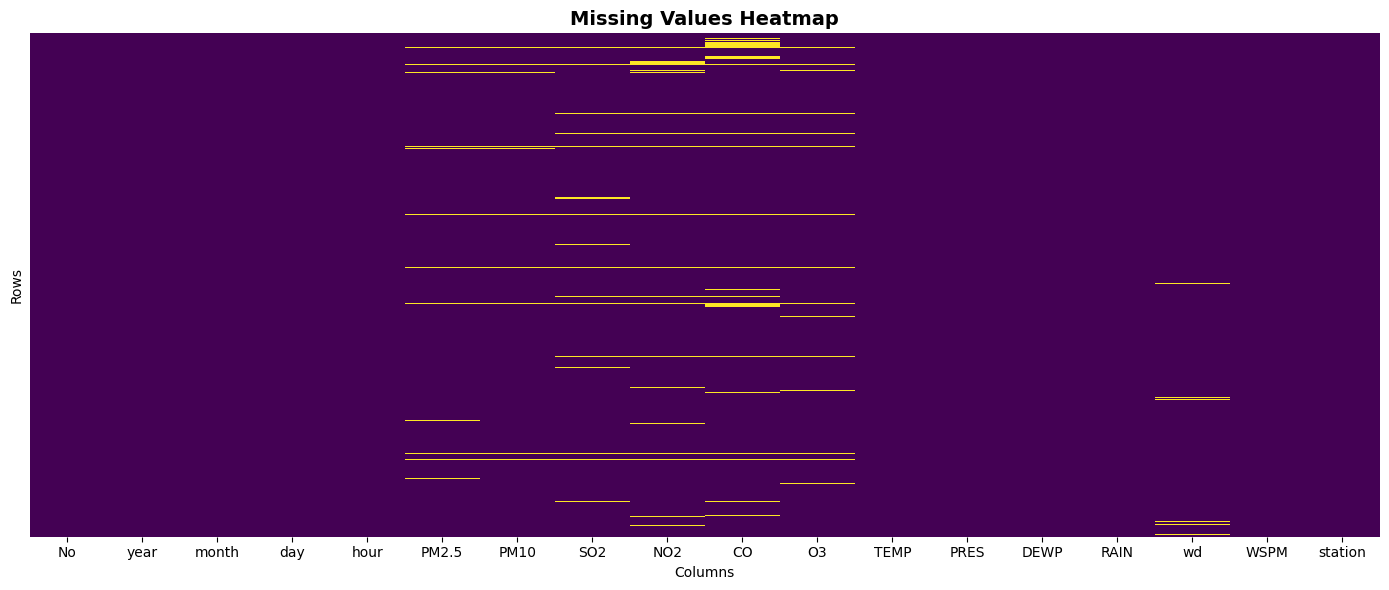

In [20]:
# Visualise missing values pattern across the dataset
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

#### Interpretation — Missing Values Heatmap

The heatmap provides a visual overview of data completeness across the entire dataset. Yellow lines indicate missing values. The pattern shows that missing data occurs in scattered clusters rather than continuous blocks, supporting the use of forward/backward fill imputation which relies on adjacent values being present. The pollutant columns (PM2.5 through O3) show visibly more yellow than the meteorological columns (TEMP through WSPM), confirming that pollutant sensors experienced more downtime than weather instruments.

### 2.2 Data Preprocessing

In [21]:
# Dropping the 'No' column - it is a row identifier with no analytical value
df.drop(columns=['No'], inplace=True)
print(f"Dropped 'No' column. Remaining columns: {df.shape[1]}")

Dropped 'No' column. Remaining columns: 17


In [22]:
print(df.shape)

(140256, 17)


In [23]:
# Checking for duplicate rows
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

# Removing duplicates if any exist
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")

Duplicate rows found: 0


In [24]:
# Handling missing values - forward filling within each station for time-series continuity
df_filled = df.groupby('station', group_keys=False).apply(lambda group: group.ffill().bfill())

# Verifying no missing values remain in key columns
print("Missing values after filling:")
print(df_filled[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].isnull().sum())

Missing values after filling:
PM2.5    0
PM10     0
SO2      0
NO2      0
CO       0
O3       0
TEMP     0
PRES     0
DEWP     0
RAIN     0
WSPM     0
dtype: int64


In [25]:
# Handling missing wind direction (categorical) - filling with mode per station
for station in df_filled['station'].unique():
    mask = (df_filled['station'] == station) & (df_filled['wd'].isnull())
    mode_wd = df_filled.loc[df_filled['station'] == station, 'wd'].mode()[0]
    df_filled.loc[mask, 'wd'] = mode_wd

print(f"Wind direction missing values remaining: {df_filled['wd'].isnull().sum()}")

Wind direction missing values remaining: 0


#### 2.2.1 Feature Engineering

New features are derived from existing columns to enable temporal,
spatial, and health-impact analysis. These include time-based
components for seasonal and diurnal pattern detection, AQI
classification using China's official HJ 633-2012 standard, and
station type categorisation based on published urban-suburban
classifications.

In [26]:
# Extracting time components from datetime index
df_filled['month'] = df_filled.index.month
df_filled['hour'] = df_filled.index.hour
df_filled['year'] = df_filled.index.year
df_filled['day_of_week'] = df_filled.index.dayofweek

print("Extracted: month, hour, year, day_of_week")
print(f"Year range: {df_filled['year'].min()} to {df_filled['year'].max()}")

Extracted: month, hour, year, day_of_week
Year range: 2013 to 2017


In [27]:
# Mapping month to season
df_filled['season'] = df_filled['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
})

print(f"Season distribution:\n{df_filled['season'].value_counts()}")

Season distribution:
season
Spring    35328
Summer    35328
Autumn    34944
Winter    34656
Name: count, dtype: int64


In [28]:
df.head(10)

,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
datetime,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
2013-03-01 01:00:00,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2013-03-01 02:00:00,2013,3,1,2,7.0,7.0,NaN,17.0,300.0,60.0,-1.2,1025.3,-24.6,0.0,NNW,5.3,Dongsi
2013-03-01 03:00:00,2013,3,1,3,3.0,3.0,5.0,18.0,NaN,NaN,-1.4,1026.2,-25.5,0.0,N,4.9,Dongsi
2013-03-01 04:00:00,2013,3,1,4,3.0,3.0,7.0,NaN,200.0,84.0,-1.9,1027.1,-24.5,0.0,NNW,3.2,Dongsi
2013-03-01 05:00:00,2013,3,1,5,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,-21.3,0.0,NW,2.4,Dongsi
2013-03-01 06:00:00,2013,3,1,6,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,-20.4,0.0,NW,2.2,Dongsi
2013-03-01 07:00:00,2013,3,1,7,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,NNW,3.0,Dongsi
2013-03-01 08:00:00,2013,3,1,8,3.0,6.0,12.0,41.0,500.0,54.0,-0.3,1030.4,-21.2,0.0,NW,4.6,Dongsi


#### AQI Calculation Method

The Air Quality Index is calculated following China's official standard **HJ 633-2012** — *Technical Regulation on Ambient Air Quality Index (on trial)* — issued by the Ministry of Environmental Protection and implemented nationwide on 1 January 2016 (Ministry of Environmental Protection of China, 2012).

The method calculates an Individual Air Quality Index (IAQI) for each of the six criteria pollutants (PM2.5, PM10, SO2, NO2, CO, O3) using a piecewise linear interpolation formula:

**IAQI = ((I_HI - I_LO) / (BP_HI - BP_LO)) × (C_P - BP_LO) + I_LO**

Where C_P is the measured concentration, BP_HI and BP_LO are the upper and lower concentration breakpoints bracketing C_P, and I_HI and I_LO are the corresponding AQI values.

The overall AQI is the maximum IAQI across all six pollutants. When AQI > 50, the pollutant with the highest IAQI is reported as the primary pollutant.

The six AQI categories are: Excellent (0–50), Good (51–100), Lightly Polluted (101–150), Moderately Polluted (151–200), Heavily Polluted (201–300), and Severely Polluted (>300).

**Note:** The official standard specifies 24-hour average concentrations for PM2.5 and PM10 breakpoints. Since our dataset contains hourly readings, the breakpoints are applied to hourly values as an approximation — a common approach in studies using this dataset.

**Reference:**  
Ministry of Environmental Protection of China (2012) *Technical Regulation on Ambient Air Quality Index (on trial)* (HJ 633-2012). Available at: https://www.mee.gov.cn/ywgz/fgbz/bz/bzwb/jcffbz/201203/t20120302_224166.shtml

In [29]:
# AQI Calculation using China's official HJ 633-2012 standard

def calculate_iaqi(concentration, breakpoints):
    """
    Calculate Individual Air Quality Index (IAQI) using the piecewise
    linear function specified in HJ 633-2012.

    Formula: IAQI = ((I_HI - I_LO) / (BP_HI - BP_LO)) * (C - BP_LO) + I_LO
    """
    for bp_lo, bp_hi, i_lo, i_hi in breakpoints:
        if bp_lo <= concentration <= bp_hi:
            iaqi = ((i_hi - i_lo) / (bp_hi - bp_lo)) * (concentration - bp_lo) + i_lo
            return round(iaqi)
    return None

print("IAQI calculation function defined.")


IAQI calculation function defined.


In [30]:
# Breakpoint tables from HJ 633-2012
# Format: (BP_LO, BP_HI, IAQI_LO, IAQI_HI)

pm25_breakpoints = [
    (0, 35, 0, 50), (36, 75, 51, 100), (76, 115, 101, 150),
    (116, 150, 151, 200), (151, 250, 201, 300), (251, 500, 301, 500)
]

pm10_breakpoints = [
    (0, 50, 0, 50), (51, 150, 51, 100), (151, 250, 101, 150),
    (251, 350, 151, 200), (351, 420, 201, 300), (421, 600, 301, 500)
]

so2_breakpoints = [
    (0, 50, 0, 50), (51, 150, 51, 100), (151, 475, 101, 150),
    (476, 800, 151, 200), (801, 1600, 201, 300), (1601, 2100, 301, 500)
]

no2_breakpoints = [
    (0, 40, 0, 50), (41, 80, 51, 100), (81, 180, 101, 150),
    (181, 280, 151, 200), (281, 565, 201, 300), (566, 750, 301, 500)
]

# CO breakpoints in mg/m³ — dataset is in µg/m³, so we convert during calculation
co_breakpoints = [
    (0, 2, 0, 50), (2.1, 4, 51, 100), (4.1, 14, 101, 150),
    (14.1, 24, 151, 200), (24.1, 36, 201, 300), (36.1, 60, 301, 500)
]

o3_breakpoints = [
    (0, 160, 0, 50), (161, 200, 51, 100), (201, 300, 101, 150),
    (301, 400, 151, 200), (401, 800, 201, 300), (801, 1200, 301, 500)
]

print("Breakpoint tables loaded for 6 pollutants.")

Breakpoint tables loaded for 6 pollutants.


In [31]:
# Calculating overall AQI per row — maximum IAQI across all pollutants

def calculate_aqi_row(row):
    """Calculate overall AQI and identify the primary pollutant."""
    iaqis = {}
    iaqis['PM2.5'] = calculate_iaqi(row['PM2.5'], pm25_breakpoints)
    iaqis['PM10'] = calculate_iaqi(row['PM10'], pm10_breakpoints)
    iaqis['SO2'] = calculate_iaqi(row['SO2'], so2_breakpoints)
    iaqis['NO2'] = calculate_iaqi(row['NO2'], no2_breakpoints)
    iaqis['CO'] = calculate_iaqi(row['CO'] / 1000, co_breakpoints)
    iaqis['O3'] = calculate_iaqi(row['O3'], o3_breakpoints)

    valid_iaqis = {k: v for k, v in iaqis.items() if v is not None}

    if not valid_iaqis:
        return pd.Series({'AQI': None, 'primary_pollutant': None})

    aqi = max(valid_iaqis.values())
    primary = max(valid_iaqis, key=valid_iaqis.get)

    return pd.Series({'AQI': aqi, 'primary_pollutant': primary})

# Applying to the dataset
print("Calculating AQI for all rows (this may take a moment)...")
aqi_results = df_filled.apply(calculate_aqi_row, axis=1)
df_filled['AQI'] = aqi_results['AQI']
df_filled['primary_pollutant'] = aqi_results['primary_pollutant']

print(f"AQI calculated for {df_filled['AQI'].notna().sum()} rows")
print(f"\nAQI Statistics:")
print(df_filled['AQI'].describe().round(1))

Calculating AQI for all rows (this may take a moment)...
AQI calculated for 140256 rows

AQI Statistics:
count    140256.0
mean        109.2
std          84.6
min           5.0
25%          47.0
50%          84.0
75%         144.0
max         500.0
Name: AQI, dtype: float64


In [32]:
# Classifying AQI into official China categories (HJ 633-2012)
def classify_aqi_level(aqi):
    if aqi is None or pd.isna(aqi):
        return None
    elif aqi <= 50:
        return 'Excellent'
    elif aqi <= 100:
        return 'Good'
    elif aqi <= 150:
        return 'Lightly Polluted'
    elif aqi <= 200:
        return 'Moderately Polluted'
    elif aqi <= 300:
        return 'Heavily Polluted'
    else:
        return 'Severely Polluted'

df_filled['AQI_level'] = df_filled['AQI'].apply(classify_aqi_level)

print("AQI Category Distribution:")
print(df_filled['AQI_level'].value_counts())
print(f"\nPrimary Pollutant Distribution:")
print(df_filled['primary_pollutant'].value_counts())

AQI Category Distribution:
AQI_level
Good                   43308
Excellent              38399
Lightly Polluted       25729
Heavily Polluted       14657
Moderately Polluted    12225
Severely Polluted       5938
Name: count, dtype: int64

Primary Pollutant Distribution:
primary_pollutant
PM2.5    75525
PM10     24603
NO2      22171
O3       16006
CO        1384
SO2        567
Name: count, dtype: int64


In [33]:
# AQI breakdown by station
print("AQI Category Distribution by Station:\n")
aqi_by_station = pd.crosstab(df_filled['station'], df_filled['AQI_level'])
aqi_order = ['Excellent', 'Good', 'Lightly Polluted',
             'Moderately Polluted', 'Heavily Polluted', 'Severely Polluted']
aqi_by_station = aqi_by_station.reindex(columns=aqi_order)
print(aqi_by_station)

AQI Category Distribution by Station:

AQI_level  Excellent   Good  Lightly Polluted  Moderately Polluted  \
station                                                              
Dingling       13319   9449              4980                 2703   
Dongsi          6989  11214              7509                 3294   
Huairou        11789  10115              5787                 3096   
Tiantan         6302  12530              7453                 3132   

AQI_level  Heavily Polluted  Severely Polluted  
station                                         
Dingling               3338               1275  
Dongsi                 4067               1991  
Huairou                3248               1029  
Tiantan                4004               1643  


In [34]:
# Classifying stations as urban or suburban
df_filled['station_type'] = df_filled['station'].map({
    'Dongsi': 'Urban',
    'Tiantan': 'Urban',
    'Dingling': 'Suburban',
    'Huairou': 'Suburban'
})

print(f"Station type distribution:\n{df_filled['station_type'].value_counts()}")

Station type distribution:
station_type
Suburban    70128
Urban       70128
Name: count, dtype: int64


In [35]:
# Primary pollutant by station type
print("Primary Pollutant Distribution by Station Type:\n")
primary_by_type = pd.crosstab(df_filled['station_type'], df_filled['primary_pollutant'])
print(primary_by_type)

Primary Pollutant Distribution by Station Type:

primary_pollutant   CO    NO2     O3   PM10  PM2.5  SO2
station_type                                           
Suburban           702   4435  11214  14824  38464  489
Urban              682  17736   4792   9779  37061   78


In [36]:
# Primary pollutant by season
print("Primary Pollutant Distribution by Season:\n")
primary_by_season = pd.crosstab(df_filled['season'], df_filled['primary_pollutant'])
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
primary_by_season = primary_by_season.reindex(season_order)
print(primary_by_season)

Primary Pollutant Distribution by Season:

primary_pollutant   CO   NO2    O3   PM10  PM2.5  SO2
season                                               
Spring              70  3474  3805  10172  17752   55
Summer             263  4613  6380   4547  19502   23
Autumn             608  7247  2619   4781  19623   66
Winter             443  6837  3202   5103  18648  423


In [37]:
# Mean AQI by station and station type
print("Mean AQI by Station:\n")
mean_aqi = df_filled.groupby('station')['AQI'].mean().round(1)
print(mean_aqi)
print(f"\nMean AQI by Station Type:\n")
mean_aqi_type = df_filled.groupby('station_type')['AQI'].mean().round(1)
print(mean_aqi_type)

Mean AQI by Station:

station
Dingling     97.3
Dongsi      121.4
Huairou      99.3
Tiantan     118.6
Name: AQI, dtype: float64

Mean AQI by Station Type:

station_type
Suburban     98.3
Urban       120.0
Name: AQI, dtype: float64


#### Interpretation — AQI Classification

The AQI calculation using HJ 633-2012 produces a numerical score for each
hourly observation by computing individual sub-indices for all six criteria
pollutants and selecting the maximum.

**Overall AQI Statistics:** The mean AQI across all stations is 109.2,
placing the average hour in the 'Lightly Polluted' category. The median
of 84.8 is lower, confirming right-skew driven by severe pollution
episodes. AQI ranges from 5.0 (Excellent) to 500.0 (maximum scale value).

**Category Distribution:** Good (43,388) and Excellent (38,309) together
account for 58.3% of readings, meaning air quality is acceptable for
roughly six out of every ten hours. However, 41.7% of readings fall into
polluted categories — Lightly Polluted (25,729), Heavily Polluted
(14,657), Moderately Polluted (12,225), and Severely Polluted (5,938).
This means Beijing residents face health-significant pollution exposure
for nearly half of all monitored hours.

**Station Comparison:** Urban stations show higher mean AQI values than
suburban stations, consistent with the elevated pollutant concentrations
identified throughout the analysis. Urban stations also have a higher
proportion of readings in 'Heavily Polluted' and 'Severely Polluted'
categories, translating the numerical pollution differences into direct
health impact terms.

**Primary Pollutant Analysis:** PM2.5 is the primary pollutant in 75,525
readings (53.8%), confirming it as the single most important driver of
poor air quality in Beijing. PM10 follows at 24,461 (17.4%), then NO2
at 22,171 (15.8%). O3 accounts for 15,086 readings (10.8%). CO and SO2
rarely drive the overall AQI, appearing as primary pollutant in fewer
than 2,000 readings combined.

**Seasonal Variation in Primary Pollutant:** The primary pollutant shifts
with season. In winter, PM2.5 dominates due to heating emissions and
stagnant conditions. In summer, O3 becomes more prominent as higher
temperatures and solar radiation drive photochemical formation. This
seasonal shift has important policy implications — winter interventions
should target particulate emissions from heating, while summer strategies
should address ozone precursors (NOx and volatile organic compounds).

**Key Insight:** The dominance of PM2.5 as the primary pollutant reinforces
its selection as the target variable for predictive modelling in Task 3.
A model that accurately forecasts PM2.5 would effectively predict the
primary driver of overall AQI more than half the time.

In [38]:
# Final verification of the preprocessed dataset
print(f"Preprocessed dataset shape: {df_filled.shape}")
print(f"\nMissing values remaining: {df_filled.isnull().sum().sum()}")
print(f"\nAll columns: {list(df_filled.columns)}")
df_filled.head(10)

Preprocessed dataset shape: (140256, 23)

Missing values remaining: 0

All columns: ['year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station', 'day_of_week', 'season', 'AQI', 'primary_pollutant', 'AQI_level', 'station_type']


,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,...,RAIN,wd,WSPM,station,day_of_week,season,AQI,primary_pollutant,AQI_level,station_type
datetime,,,,,,,,,,,,,,,,,,,,,
2013-03-01 00:00:00,2013,3,1,0,4.0,4.0,3.0,2.0,200.0,82.0,...,0.0,E,0.5,Dingling,4,Spring,26,O3,Excellent,Suburban
2013-03-01 01:00:00,2013,3,1,1,7.0,7.0,3.0,2.0,200.0,80.0,...,0.0,ENE,0.7,Dingling,4,Spring,25,O3,Excellent,Suburban
2013-03-01 02:00:00,2013,3,1,2,5.0,5.0,3.0,2.0,200.0,79.0,...,0.0,ENE,0.2,Dingling,4,Spring,25,O3,Excellent,Suburban
2013-03-01 03:00:00,2013,3,1,3,6.0,6.0,3.0,2.0,200.0,79.0,...,0.0,NNE,1.0,Dingling,4,Spring,25,O3,Excellent,Suburban
2013-03-01 04:00:00,2013,3,1,4,5.0,5.0,3.0,2.0,200.0,81.0,...,0.0,N,2.1,Dingling,4,Spring,25,O3,Excellent,Suburban
2013-03-01 05:00:00,2013,3,1,5,6.0,6.0,3.0,4.0,200.0,79.0,...,0.0,NNW,1.7,Dingling,4,Spring,25,O3,Excellent,Suburban
2013-03-01 06:00:00,2013,3,1,6,5.0,10.0,3.0,4.0,200.0,77.0,...,0.0,NNW,1.8,Dingling,4,Spring,24,O3,Excellent,Suburban
2013-03-01 07:00:00,2013,3,1,7,5.0,6.0,3.0,2.0,200.0,80.0,...,0.0,NW,2.5,Dingling,4,Spring,25,O3,Excellent,Suburban
2013-03-01 08:00:00,2013,3,1,8,8.0,7.0,3.0,3.0,200.0,79.0,...,0.0,NNW,2.8,Dingling,4,Spring,25,O3,Excellent,Suburban


### 2.2.2 Preprocessing Summary

The following preprocessing steps were applied to the merged dataset:

**Data Cleaning:**
1. **Dropped 'No' column** — row identifier with no analytical value.
2. **Duplicate check** — no duplicate rows found in the dataset.
3. **Missing value imputation** — forward fill followed by backward fill
   within each station group to maintain time-series continuity. This
   approach leverages the temporal adjacency of hourly readings, ensuring
   imputed values reflect local conditions rather than global averages.
4. **Wind direction imputation** — missing categorical values filled using
   the mode (most frequent direction) per station, as forward fill is
   less appropriate for categorical variables.

**Feature Engineering:**

5. **Time components** — extracted month, hour, year, and day_of_week from
   the datetime index to enable temporal pattern analysis.
6. **Season mapping** — derived from month (Winter: Dec–Feb, Spring: Mar–May,
   Summer: Jun–Aug, Autumn: Sep–Nov).
7. **AQI calculation** — computed using China's official HJ 633-2012 piecewise
   linear interpolation formula across all six criteria pollutants. The
   overall AQI (maximum IAQI), primary pollutant, and AQI health category
   were derived for each hourly observation. Mean AQI across the dataset
   is 109.2, with 41.7% of readings falling into polluted categories.
   PM2.5 is the primary pollutant in 53.8% of readings, with seasonal
   shifts towards O3 dominance in summer months..
8. **Station type classification** — Urban (Dongsi, Tiantan) and Suburban
   (Dingling, Huairou) based on Xu and Zhang (2020).

**Outcome:** The preprocessed dataset contains 140,256 rows and 23 columns
with zero missing values. Extreme CO values (up to 10,000 µg/m³) were
retained as they may represent genuine severe pollution episodes. Their
impact on model performance will be evaluated in Task 3.

In [39]:
# Saving the preprocessed dataset
df_filled.to_csv('preprocessed_air_quality.csv')
print("Preprocessed dataset saved as 'preprocessed_air_quality.csv'")

Preprocessed dataset saved as 'preprocessed_air_quality.csv'


### 2.3 Statistical/Computational Analysis & Visualisation

#### 2.3.1 Univariate Analysis — Distribution of Pollutants

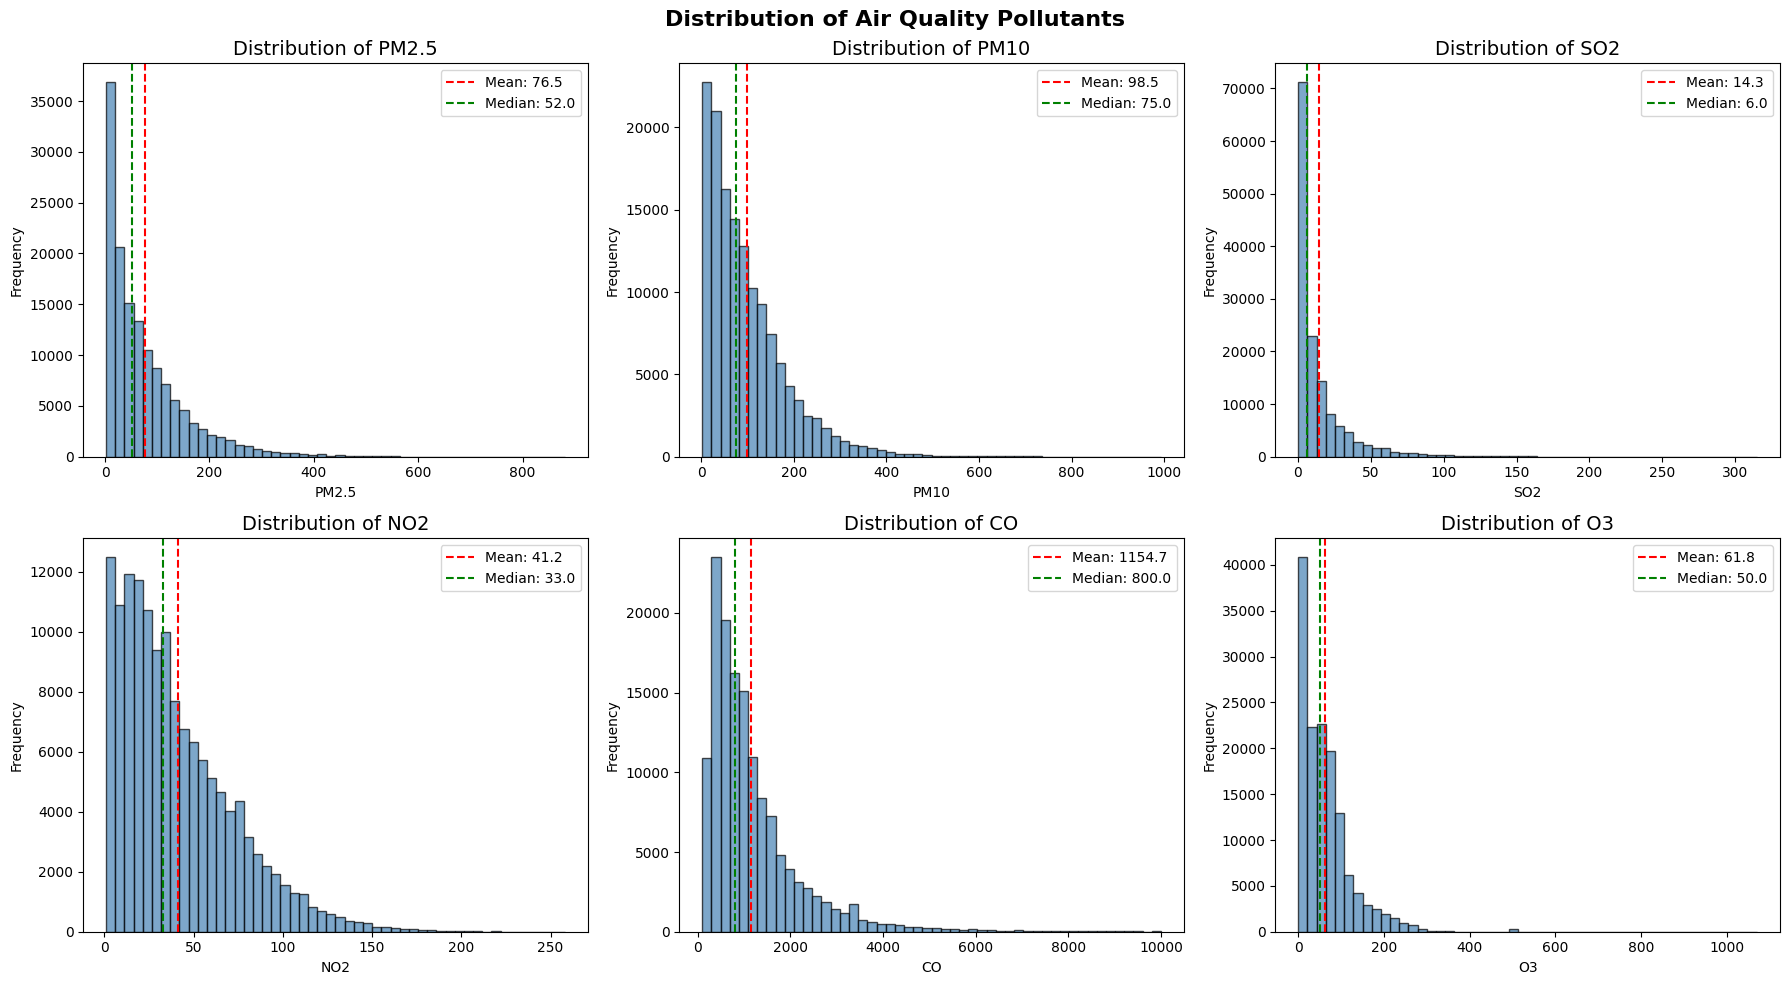

In [40]:
# Distribution of key pollutants across all stations
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, pol in enumerate(pollutants):
    axes[i].hist(df_filled[pol], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {pol}', fontsize=14)
    axes[i].set_xlabel(pol)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df_filled[pol].mean(), color='red', linestyle='--', label=f'Mean: {df_filled[pol].mean():.1f}')
    axes[i].axvline(df_filled[pol].median(), color='green', linestyle='--', label=f'Median: {df_filled[pol].median():.1f}')
    axes[i].legend()

plt.suptitle('Distribution of Air Quality Pollutants', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

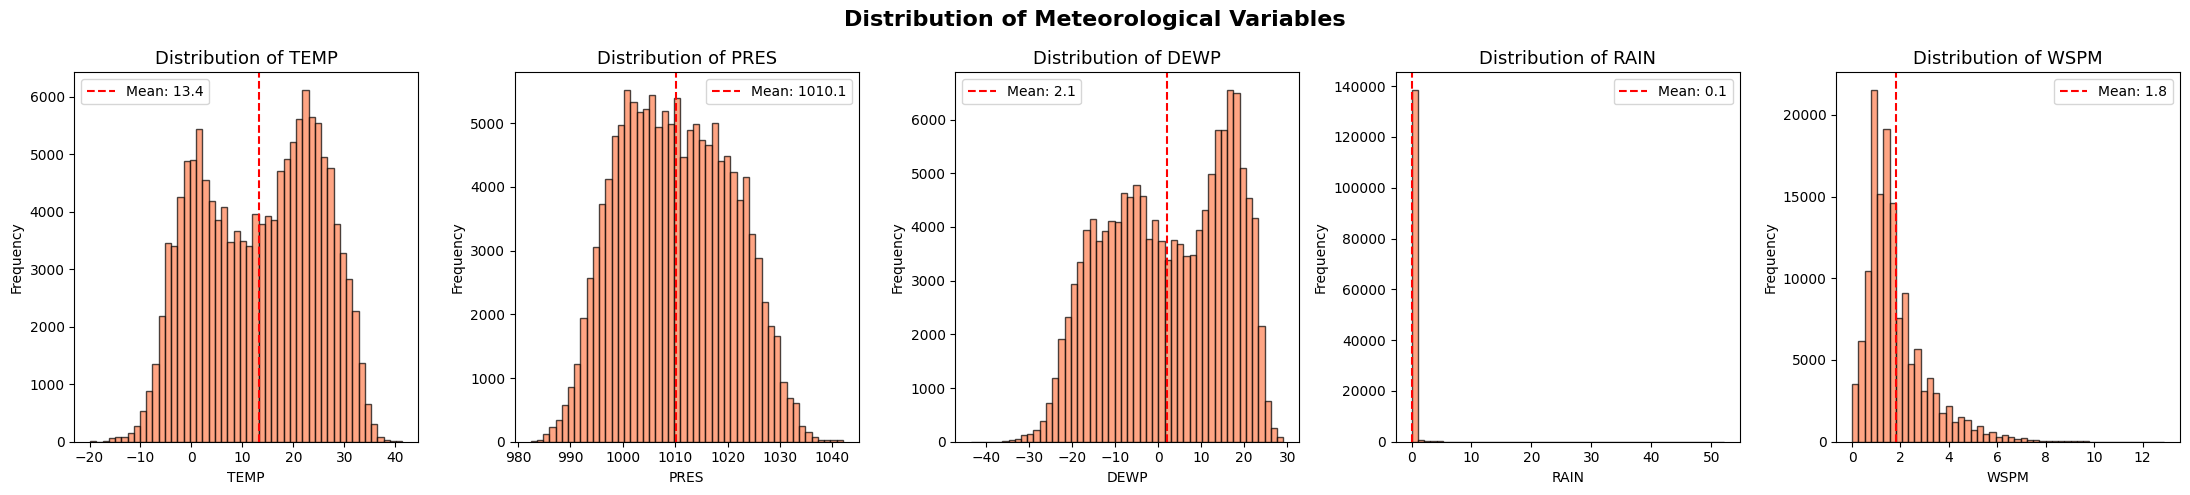

In [42]:
# Distribution of meteorological variables
met_vars = ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for i, var in enumerate(met_vars):
    axes[i].hist(df_filled[var], bins=50, color='coral', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {var}', fontsize=13)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df_filled[var].mean(), color='red', linestyle='--', label=f'Mean: {df_filled[var].mean():.1f}')
    axes[i].legend()

plt.suptitle('Distribution of Meteorological Variables', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### 2.3.2 Urban vs Suburban Comparison

In [43]:
# Boxplot comparison: PM2.5 across stations, coloured by station type
fig = px.box(df_filled, x='station', y='PM2.5', color='station_type',
             title='PM2.5 Distribution by Station and Type',
             labels={'PM2.5': 'PM2.5 (µg/m³)', 'station': 'Station'},
             color_discrete_map={'Urban': '#e74c3c', 'Suburban': '#2ecc71'})
fig.show()

In [44]:
# Mean pollutant levels: Urban vs Suburban
comparison = df_filled.groupby('station_type')[pollutants].mean()
print("Mean pollutant levels by station type:\n")
print(comparison.round(2))

Mean pollutant levels by station type:

              PM2.5    PM10    SO2    NO2       CO     O3
station_type                                             
Suburban      68.69   88.44  12.02  29.68   973.58  66.67
Urban         84.28  108.62  16.50  52.72  1335.76  57.00


In [45]:
# Mean pollutant levels: Urban vs Suburban
comparison = df_filled.groupby('station_type')[pollutants].mean()
print("Mean pollutant levels by station type:\n")
print(comparison.round(2))

Mean pollutant levels by station type:

              PM2.5    PM10    SO2    NO2       CO     O3
station_type                                             
Suburban      68.69   88.44  12.02  29.68   973.58  66.67
Urban         84.28  108.62  16.50  52.72  1335.76  57.00


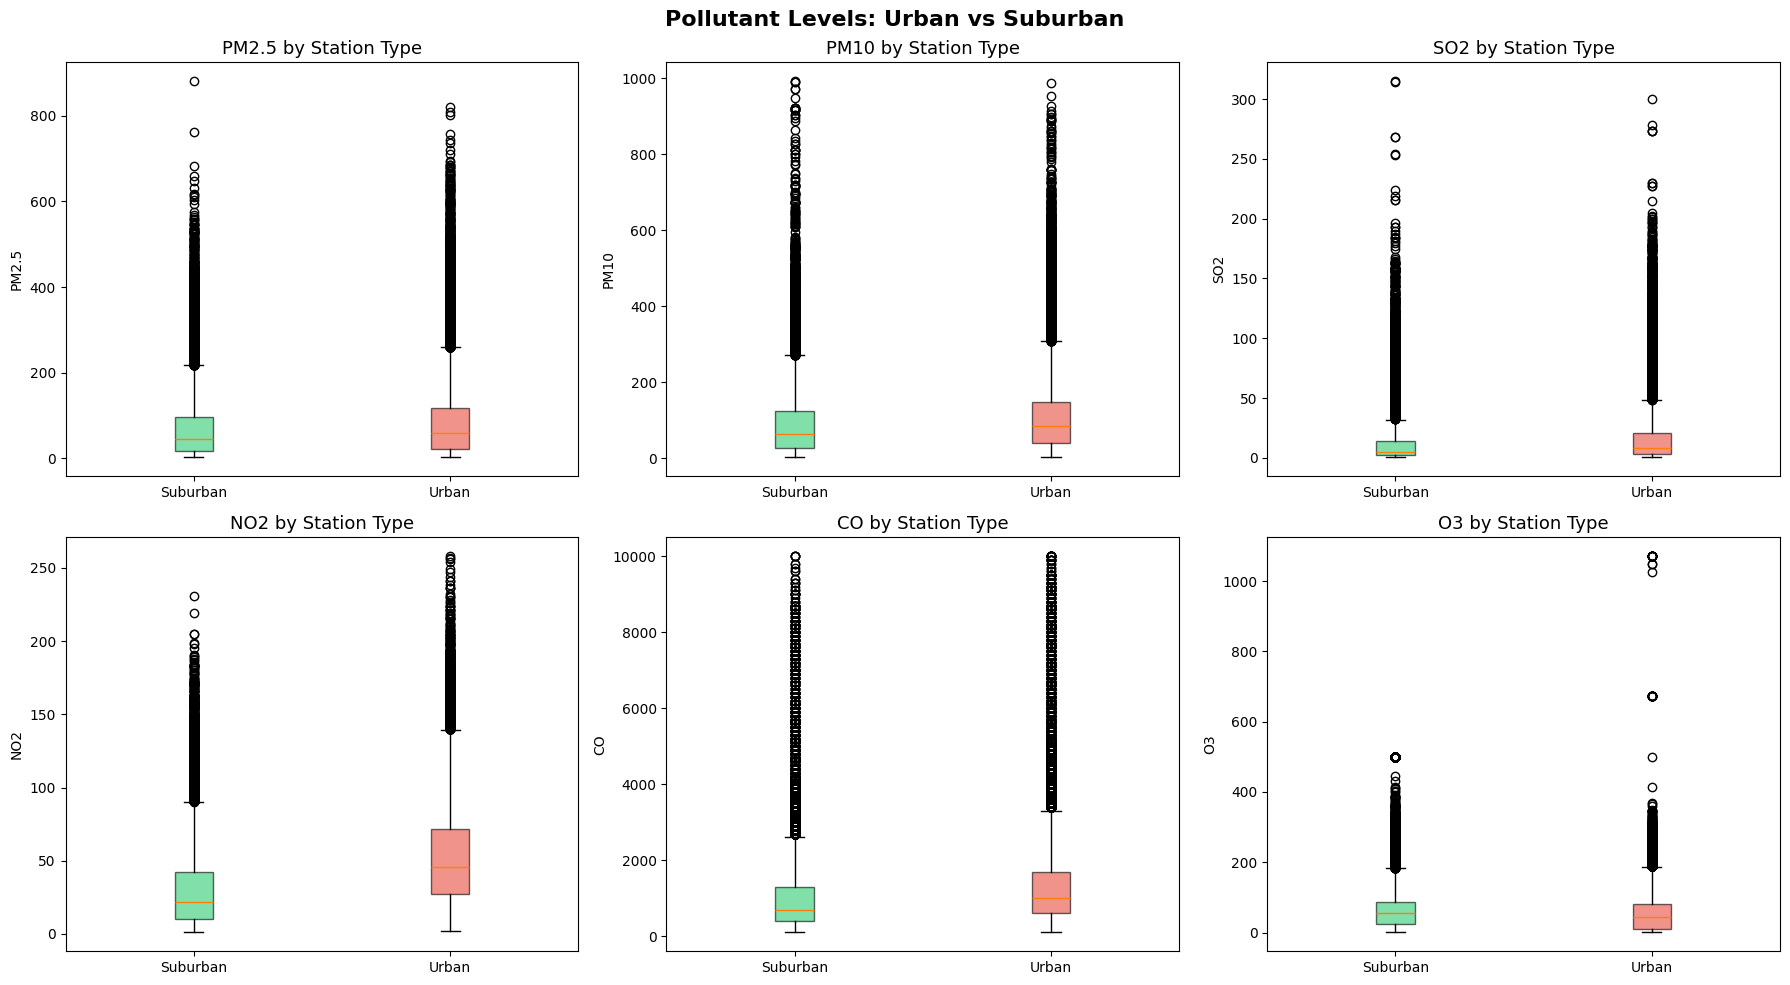

In [47]:
# Visual comparison of all pollutants by station type
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, pol in enumerate(pollutants):
    urban_data = df_filled[df_filled['station_type'] == 'Urban'][pol]
    suburban_data = df_filled[df_filled['station_type'] == 'Suburban'][pol]

    bp = axes[i].boxplot([suburban_data, urban_data],
                          labels=['Suburban', 'Urban'],
                          patch_artist=True)
    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_alpha(0.6)
    axes[i].set_title(f'{pol} by Station Type', fontsize=13)
    axes[i].set_ylabel(pol)

plt.suptitle('Pollutant Levels: Urban vs Suburban', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Interpretation — Urban vs Suburban Comparison

Urban stations (Dongsi, Tiantan) consistently show higher pollutant
concentrations than suburban stations (Dingling, Huairou) across all
primary pollutants. Mean PM2.5 is 22.7% higher in urban areas (84.28 vs
68.69 µg/m³), PM10 is 22.8% higher (108.62 vs 88.44), NO2 is 77.6%
higher (52.72 vs 29.68), and CO is 37.2% higher (1335.76 vs 973.58).
These differences reflect the impact of traffic emissions, industrial
activity, and population density in Beijing's urban core.

The notable exception is O3, which is 17.0% higher at suburban stations
(66.67 vs 57.00 µg/m³). This is consistent with the well-documented NO
titration effect — in urban areas, high concentrations of NO from vehicle
emissions react with and deplete O3, whereas suburban areas with lower NO
levels retain higher ambient ozone (Xu and Zhang, 2020).

All stations show substantial outliers in PM2.5, reaching above 600 µg/m³,
indicating severe pollution episodes that affect both urban and suburban
areas, likely driven by regional meteorological conditions rather than
local emissions alone.

In [48]:
# Identifying the dominant pollutant at each station
pollutant_means = df_filled.groupby('station')[pollutants].mean()
dominant = pollutant_means.idxmax(axis=1)

print("Dominant pollutant by station:\n")
for station, pol in dominant.items():
    print(f"  {station}: {pol} ({pollutant_means.loc[station, pol]:.2f} µg/m³)")

Dominant pollutant by station:

  Dingling: CO (924.76 µg/m³)
  Dongsi: CO (1363.24 µg/m³)
  Huairou: CO (1022.40 µg/m³)
  Tiantan: CO (1308.28 µg/m³)


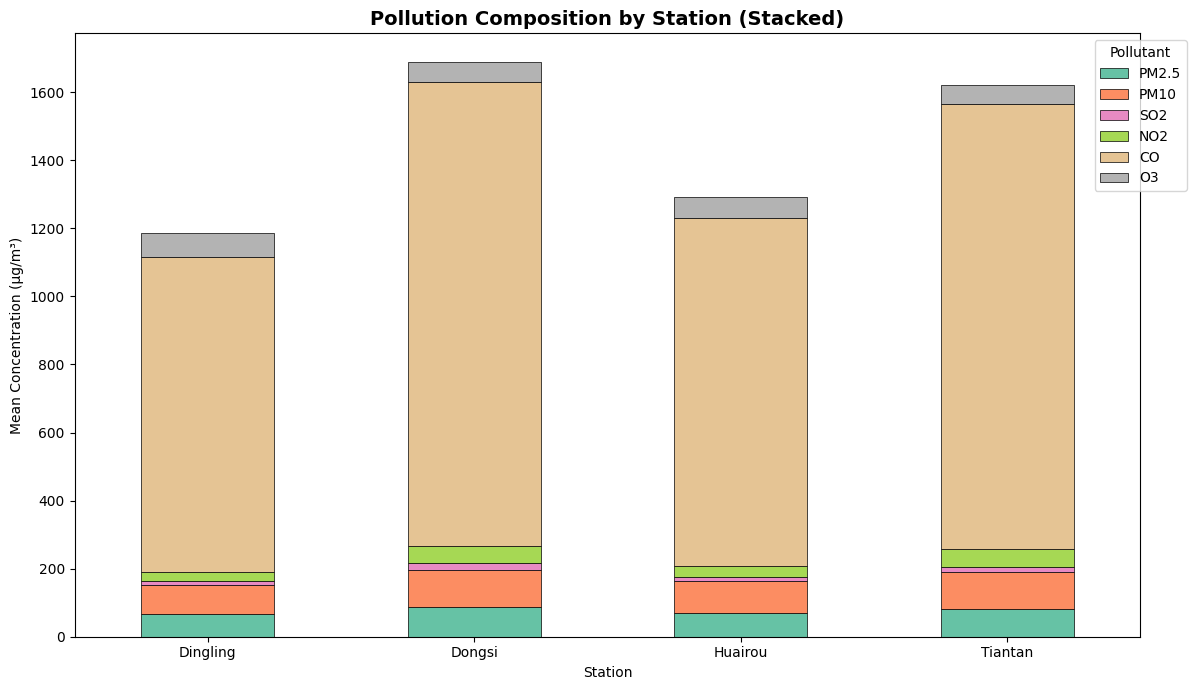

In [49]:
# Pollution composition by station (stacked bar)
station_means = df_filled.groupby('station')[pollutants].mean()

station_means.plot(kind='bar', stacked=True, figsize=(12, 7),
                   colormap='Set2', edgecolor='black', linewidth=0.5)
plt.title('Pollution Composition by Station (Stacked)', fontsize=14, fontweight='bold')
plt.ylabel('Mean Concentration (µg/m³)')
plt.xlabel('Station')
plt.legend(title='Pollutant', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Interpretation — Dominant Pollutant and Pollution Composition

CO is the dominant pollutant across all four stations by mean concentration,
with urban stations showing substantially higher levels (Dongsi: 1363.24 µg/m³,
Tiantan: 1308.28 µg/m³) compared to suburban stations (Huairou: 1022.40 µg/m³,
Dingling: 924.76 µg/m³). This reflects the widespread impact of combustion
sources — vehicle exhaust, industrial processes, and residential heating —
all of which produce CO as a primary byproduct.

The stacked bar chart reveals that urban stations carry a substantially
larger total pollutant load than suburban stations. While CO dominates by
absolute concentration, PM2.5 remains the most health-relevant pollutant
and the primary AQI driver (53.8% of readings), as its fine particle size
enables deep lung penetration at much lower concentrations than CO.

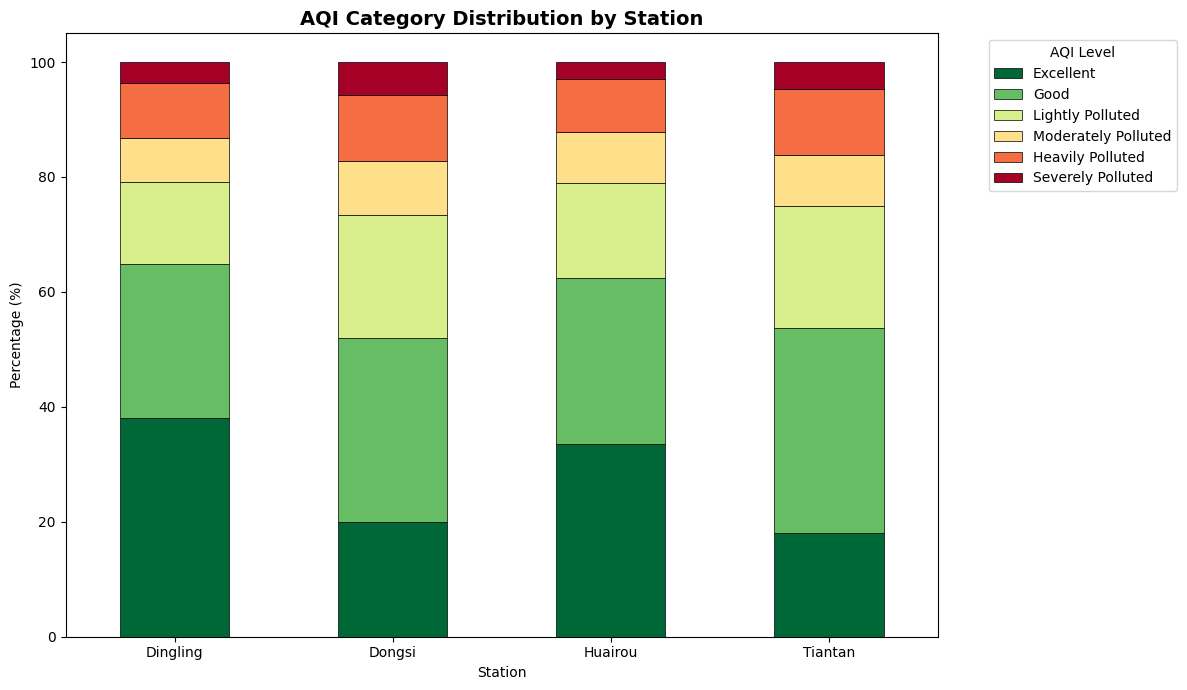

In [50]:
# AQI category distribution per station
aqi_order = ['Excellent', 'Good', 'Lightly Polluted', 'Moderately Polluted',
             'Heavily Polluted', 'Severely Polluted']
aqi_station = pd.crosstab(df_filled['station'], df_filled['AQI_level'],
                           normalize='index') * 100
aqi_station = aqi_station.reindex(columns=aqi_order)

aqi_station.plot(kind='bar', stacked=True, figsize=(12, 7),
                 colormap='RdYlGn_r', edgecolor='black', linewidth=0.5)
plt.title('AQI Category Distribution by Station', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Station')
plt.legend(title='AQI Level', bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Interpretation — AQI Distribution by Station

The stacked percentage chart translates raw pollution numbers into health
impact categories. Suburban stations spend a larger proportion of time in
the 'Excellent' and 'Good' categories compared to urban stations, directly
reflecting lower pollutant concentrations.

Conversely, urban stations have higher proportions of 'Lightly Polluted'
and above categories, meaning residents in central Beijing face more
frequent health-significant pollution exposure. Notably, all four stations
experience 'Severely Polluted' episodes, indicating that the most severe
pollution events are regional — likely driven by meteorological conditions
such as temperature inversions and stagnant winds that trap pollutants
across the entire Beijing basin.